In [1]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [32]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/5.flexible_reps")

## Goal coding (allocentric)

In [62]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import events
from GridMaze.maze import plotting as mp
from GridMaze.maze import representations as mr

In [ ]:
reload(gc)
reload(events)
reload(mp)


def plot_single_unit_trial_aligned(cluster_unique_ID, save_label=False):
    """
    Plots the average and goal-stratified trial aligned tuning curves for a given cluster,
    with maze color key (returns separate figs that can be saved separately) and assembled
    into full figure.
    """
    Cluster = gc.get_cluster(cluster_unique_ID)
    f1, ax1 = plt.subplots(1, 1, figsize=(0.5, 0.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": False, "color": "black"}, ax=ax1)
    ax1.set_xticklabels([])
    ax1.set_ylabel("Hz")

    f2, ax2 = plt.subplots(1, 1, figsize=(3, 1.5), clear=True)
    Cluster.plot_tuning(feature="trial_events", feature_kwargs={"goal_stratified": True, "smooth_SD": 15}, ax=ax2)

    f3, axes3 = plt.subplots(1, 2, figsize=(3, 1.5), clear=True)
    Cluster.plot_tuning(feature="event_aligned", feature_kwargs={"goal_stratified": True, "smooth_SD": 10}, ax=axes3)

    goals = Cluster.goals
    simple_maze = mr.get_simple_maze(Cluster.maze_name)
    f4, ax3 = plt.subplots(1, 1, figsize=(1.5, 1.5), clear=True)
    mp.plot_maze_legend(simple_maze, goals, ax=ax3)

    if save_label:
        f1.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_inset.pdf")
        f2.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_trial_aligned_tuning.pdf")
        f3.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_event_aligned_tuning.pdf")
        f4.savefig(FIG_SAVE_PATH / "example_neurons" / f"{save_label}_legend.pdf")
    else:
        return f1, f2, f3, f4

(<Figure size 100x50 with 1 Axes>,
 <Figure size 300x150 with 1 Axes>,
 <Figure size 300x150 with 2 Axes>,
 <Figure size 150x150 with 1 Axes>)

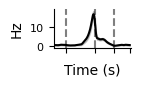

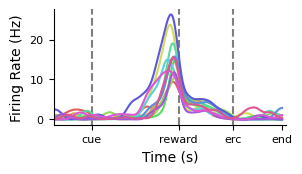

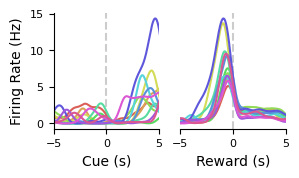

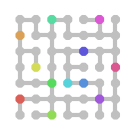

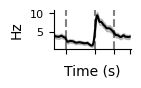

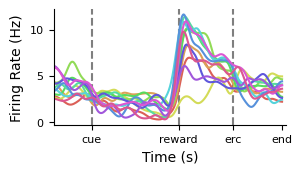

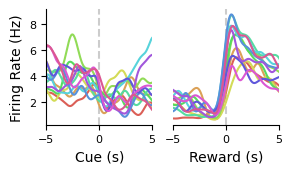

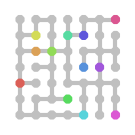

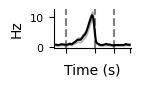

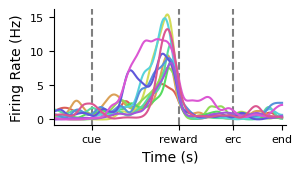

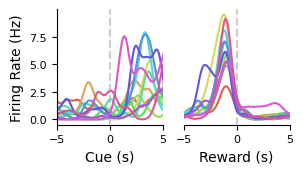

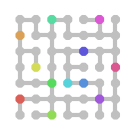

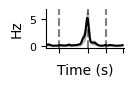

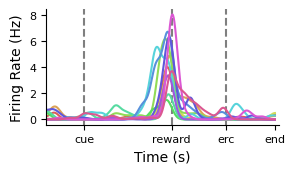

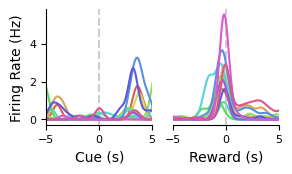

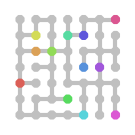

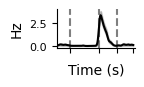

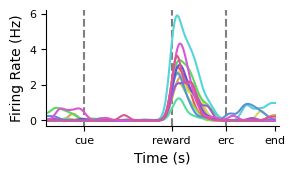

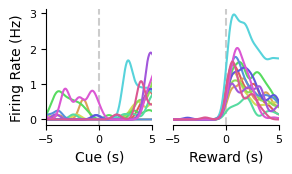

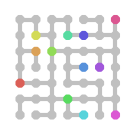

In [64]:
plot_single_unit_trial_aligned("m2.2022-07-04.maze_cluster65", save_label=False)
plot_single_unit_trial_aligned("m3.2022-07-17.maze_cluster45", save_label=False)
plot_single_unit_trial_aligned("m2.2022-07-04.maze_cluster114", save_label=False)
plot_single_unit_trial_aligned("m2.2022-07-17.maze_cluster50", save_label=False)
plot_single_unit_trial_aligned("m6.2022-07-05.maze_cluster134", save_label=False)

## Distance to goal coding

In [ ]:
# plot some individual units
from GridMaze.analysis.cluster_tuning import distance_to_goal as dtg
from GridMaze.analysis.core import get_clusters as gc
import numpy as np
from cmap import Colormap


def plot_example_neurons(clusters, ax, cmap="hls"):
    cm = Colormap(cmap)
    colors = cm(np.linspace(0, 1, len(clusters)))
    for cluster, c in zip(clusters, colors):
        Cluster = gc.get_cluster(cluster)
        Cluster.plot_tuning(feature="distance_to_goal", feature_kwargs={"normalisation": "max", "color": c}, ax=ax)
    ax.set_xlabel("Distance to Goal (m)")
    ax.set_ylabel("Norm. Firing Rate")
    return

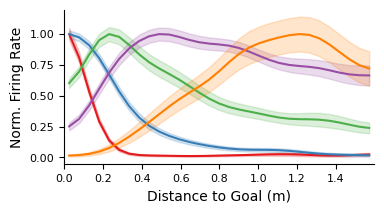

In [33]:
pos_example_clusters = [
    "m2.2022-07-03.maze_cluster43",
    "m3.2022-07-02.maze_cluster44",
    "m2.2022-07-03.maze_cluster9",
    "m7.2022-07-02.maze_cluster55",
    "m7.2022-07-25.maze_cluster73",
]

f1, ax = plt.subplots(1, 1, figsize=(4, 2))
plot_example_neurons(pos_example_clusters, ax, cmap="colorbrewer:set1_5")
f1.savefig(FIG_SAVE_PATH / "example_neurons_1.pdf")

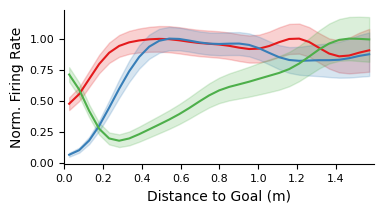

In [34]:
neg_example_clusters = [
    "m7.2022-07-10.maze_cluster8",
    "m2.2022-07-13.maze_cluster86",
    "m7.2022-07-10.maze_cluster53",
]
f2, ax = plt.subplots(1, 1, figsize=(4, 2))
plot_example_neurons(neg_example_clusters, ax, cmap="colorbrewer:set1_3")
f2.savefig(FIG_SAVE_PATH / "example_neurons_2.pdf")

In [ ]:
from GridMaze.analysis.distance_to_goal import population_tuning as pt

population_tuning_df = pt.get_population_tuning_df(late_sessions=False)

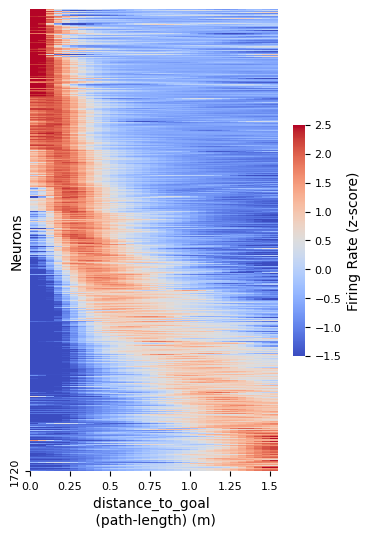

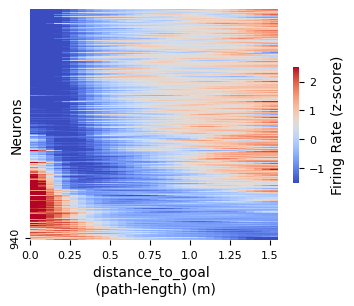

In [36]:
f1, ax = plt.subplots(1, 1, figsize=(4, 6))
reload(pt)
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="pos", ax=ax, cmap="coolwarm", v_range=(-1.5, 2.5))
# f1.savefig("../results/distance_to_goal/figures/main/heatmap_1.pdf")

f2, ax = plt.subplots(1, 1, figsize=(4, 3))
pt.plot_distance_tunned_heatmap(population_tuning_df, sign="neg", ax=ax, cmap="coolwarm", v_range=(-1.5, 2.5))
# f2.savefig("../results/distance_to_goal/figures/main/heatmap_2.pdf")

In [37]:
from GridMaze.analysis.distance_to_goal import distance_metrics as dm

cpd_summary_df = dm.get_distance_metric_CPD_summary_df(subfolder="all_trials")

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 t-stat: 4.280, p-value: 0.008


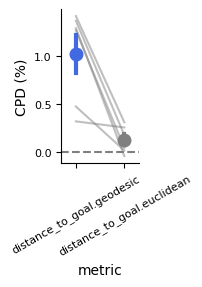

In [49]:
reload(dm)
f, ax = plt.subplots(1, 1, figsize=(1, 2))
dm.plot_cross_subject_CPD_comparison(
    cpd_summary_df,
    comparison="distance_to_goal.geodesic_vs_distance_to_goal.euclidean",
    maze_names=["maze_1", "maze_2"],
    late_sessions=True,
    ax=ax,
)

In [44]:
from GridMaze.analysis.distance_to_goal import logreg_decoder as ld

results_df = ld.load_decoding_results(subfolder="all_dist")

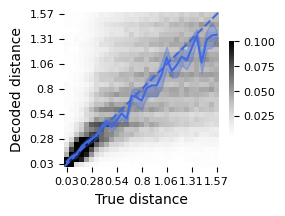

In [45]:
reload(ld)
f, ax = plt.subplots(1, 1, figsize=(2.5, 2.5))
ld.plot_distance_decoding_probs(results_df, moving_only=True, ax=ax)

In [46]:
## revisit error aligned decoding

## Supp. Goal coding

## Supp. Distance to goal 

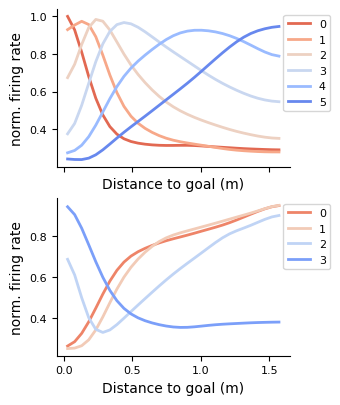

In [ ]:
reload(pt)
f, axes = plt.subplots(2, 1, figsize=(3, 4.5), sharex=True)
pt.plot_population_quantiles(
    population_tuning_df, sign="pos", normalisation_method="max", n_quantiles=6, cmap="coolwarm_r", ax=axes[0]
)
pt.plot_population_quantiles(
    population_tuning_df, sign="neg", normalisation_method="max", n_quantiles=4, cmap="coolwarm_r", ax=axes[1]
)

In [52]:
fit_summary_df = pt.get_tuning_fits_summary_df(late_sessions=False)

gamma_4p vs gaussian_4p: 
 t-stat: 7.322, p-value: 7.447e-04


(0.75, 0.85)

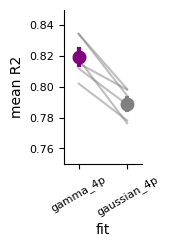

In [ ]:
reload(pt)
f, ax = plt.subplots(1, 1, figsize=(1, 2))
pt.plot_cross_subject_curve_fit_comparison(
    fit_summary_df, curve_fits=["gamma_4p", "gaussian_4p"], colors=["purple", "grey"], ax=ax
)
ax.set_ylim(0.75, 0.85)

distance_to_goal.geodesic_vs_distance_to_goal.euclidean: 
 t-stat: 4.280, p-value: 0.008
distance_to_goal.geodesic_vs_distance_to_goal.manhattan: 
 t-stat: 3.935, p-value: 0.011
distance_to_goal.geodesic_vs_distance_to_goal.future: 
 t-stat: 5.521, p-value: 0.003
distance_to_goal.geodesic_vs_progress_to_goal.path_length: 
 t-stat: 4.028, p-value: 0.010
distance_to_goal.geodesic_vs_progress_to_goal.time: 
 t-stat: 5.069, p-value: 0.004
distance_to_goal.euclidean_vs_distance_to_goal.manhattan: 
 t-stat: 3.237, p-value: 0.023
distance_to_goal.euclidean_vs_distance_to_goal.future: 
 t-stat: -4.005, p-value: 0.010
distance_to_goal.euclidean_vs_progress_to_goal.path_length: 
 t-stat: 3.003, p-value: 0.030
distance_to_goal.euclidean_vs_progress_to_goal.time: 
 t-stat: 5.306, p-value: 0.003
distance_to_goal.manhattan_vs_distance_to_goal.future: 
 t-stat: -3.734, p-value: 0.014
distance_to_goal.manhattan_vs_progress_to_goal.path_length: 
 t-stat: 3.243, p-value: 0.023
distance_to_goal.manhattan

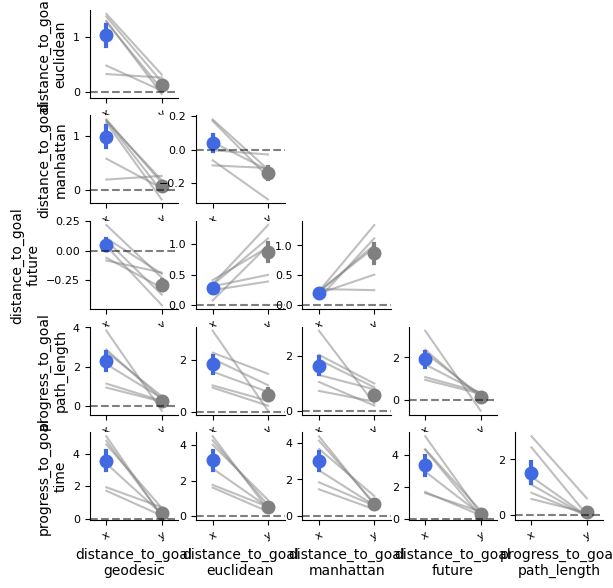

In [51]:
f, axes = plt.subplots(6, 6, figsize=(8, 8))
dm.plot_pairwise_CPD_cross_subject_comparisons(cpd_summary_df, axes=axes)